In [ ]:
import mlflow
import json

client = mlflow.MlflowClient("http://127.0.0.1:5000")
run_id = "de7c9abb82bf478ba7fb965f50178594"

# list what's in the artifacts
artifacts = client.list_artifacts(run_id)
for a in artifacts:
    print(a.path, "| dir:", a.is_dir)

config.json | dir: False
explanations | dir: True
metrics | dir: True


In [20]:
import mlflow, json, numpy as np
run_id = "4658c586d1c44fd0ae0c32c3811b7251"
npz_path = mlflow.artifacts.download_artifacts(
    artifact_uri=f"runs:/{run_id}/explanations/2025028644.jpg/sample.npz",
    tracking_uri="http://127.0.0.1:5000",
)
flat = dict(np.load(npz_path, allow_pickle=False))
attrs = json.loads(flat.pop("__attrs__").tobytes())


In [21]:
import mlflow, json, numpy as np
run_id = "96bad83c80e84f7b832988a89e68aae9"
results = mlflow.artifacts.download_artifacts(
    artifact_uri=f"runs:/{run_id}/explanations/40010133-0134.jpg/attrs.json",
    tracking_uri="http://127.0.0.1:5000",
)
print(results)
with open(results, 'r') as f:
    data = json.load(f)

/tmp/tmprc_8uwns/attrs.json


In [27]:
unts = json.loads(data['explanation_units'])
x = unts['value'][2]['attribution']

In [ ]:
len(x), len(x[0]), len(x[0][0])

import numpy as np 

x = np.array(x)

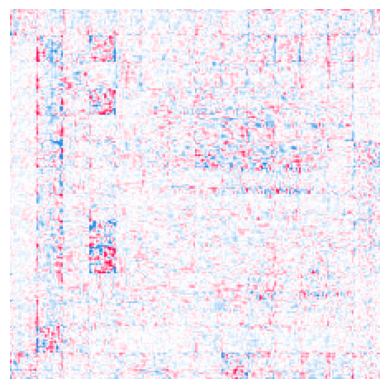

In [37]:
import matplotlib.pyplot as plt
plt.imshow(x.squeeze(0))  # remove batch dim → (224, 224, 4)
plt.axis('off')
plt.show()